# **Baseline Modeling: Logistic Regression**

## **Environment Setup**

This notebook establishes the baseline machine learning model using Logistic Regression. The modelling environment is first configured by importing the required libraries before loading the cleaned Framingham dataset for model development and evaluation.

### **Library Imports**

The required libraries are imported to support data manipulation, preprocessing, model development, and performance evaluation.

In [23]:
# Import required libraries

import pandas as pd                  # Data manipulation and analysis
import numpy as np                   # Numerical computations
import matplotlib.pyplot as plt      # Data visualization
import seaborn as sns                # Statistical data visualization
import joblib                        # Saving and loading trained models and preprocessing objects

# Import utilities for data preparation
from sklearn.model_selection import train_test_split   # Split the dataset into training and testing subsets
from sklearn.preprocessing import StandardScaler       # Standardize feature values prior to model training

# Import the Logistic Regression classifier
from sklearn.linear_model import LogisticRegression    # Binary classification model

# Import evaluation metrics for model performance assessment
from sklearn.metrics import (
    accuracy_score,                  # Overall prediction accuracy
    precision_score,                 # Proportion of correctly predicted positive cases
    recall_score,                    # Ability to identify actual positive cases
    f1_score,                        # Harmonic mean of precision and recall
    roc_auc_score,                   # Area Under the ROC Curve (AUC)
    classification_report,           # Comprehensive classification performance summary
    confusion_matrix,                # Confusion matrix for prediction outcomes
    roc_curve,                       # Receiver Operating Characteristic (ROC) curve
    RocCurveDisplay                  # Display and visualize the ROC curve
)

### **Data Ingestion**

The cleaned Framingham dataset is loaded into the working environment to facilitate model development. A preview of the dataset is then generated to confirm that it has been successfully loaded.


In [6]:
# Loads the cleaned Framingham dataset for analysis and modeling.
df = pd.read_csv('../data/processed/framingham_cleaned.csv')

print('Cleaned Framingham Data Loaded Successfully: \n')

print("Dataset shape:", df.shape)

df.head()

Cleaned Framingham Data Loaded Successfully: 

Dataset shape: (4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4,0,0,0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2,0,0,0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1,1,20,0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3,1,30,0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3,1,23,0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


### **Feature and Target Separation**

The predictor variables are separated from the target variable, `TenYearCHD`, to prepare the dataset for model development. This separation ensures that the machine learning algorithm is trained using the independent features while the target variable serves as the outcome to be predicted.

In [7]:
# Separate the predictor variables (features) and target variable
X = df.drop("TenYearCHD", axis=1)
y = df["TenYearCHD"]

# Display the dimensions of the feature matrix and target vector
print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (4240, 15)
Target vector shape: (4240,)


The feature matrix contains 4,240 observations and 15 predictor variables, while the target vector contains 4,240 corresponding outcome values. This confirms that the predictor variables and target variable have been successfully separated and are ready for the subsequent train–test split.

### **Stratified Train–Test Split**

The dataset is divided into training and testing subsets using an 80:20 ratio. Stratified sampling is employed to preserve the original class distribution of the target variable, `TenYearCHD`, in both subsets. This approach ensures that the training and testing datasets remain representative of the original dataset and supports reliable model evaluation.

In [8]:
# Split the dataset into stratified training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the dimensions of the training and testing feature sets
print("Training feature set:", X_train.shape)
print("Testing feature set:", X_test.shape)

Training feature set: (3392, 15)
Testing feature set: (848, 15)


The dataset was successfully divided into 3,392 training observations and 848 testing observations, with each observation containing 15 predictor variables. The training subset will be used for model development, while the testing subset will serve as an independent dataset for evaluating the predictive performance of the Logistic Regression model.

### **Class Distribution Verification**

The class distribution of the target variable is examined after the train–test split to verify that stratified sampling has preserved the original proportion of the majority and minority classes in both subsets.

In [9]:
# Compare the class distribution across the training and testing subsets
class_distribution = pd.DataFrame({
    "Training Set (%)": (y_train.value_counts(normalize=True) * 100).round(2),
    "Testing Set (%)": (y_test.value_counts(normalize=True) * 100).round(2)
})

class_distribution

,Training Set (%),Testing Set (%)
TenYearCHD,,
0,84.82,84.79
1,15.18,15.21


The class distribution remains nearly identical across the training and testing subsets, confirming that stratified sampling successfully preserved the original distribution of the target variable. This helps ensure that both subsets are representative of the overall dataset and supports unbiased model training and evaluation.

### **Feature Scaling**

Logistic Regression is sensitive to differences in feature scales. Therefore, the predictor variables are standardized using `StandardScaler`, which transforms each feature to have a mean of approximately zero and a standard deviation of one. To prevent data leakage, the scaler is fitted only on the training data and subsequently applied to both the training and testing subsets.

In [11]:
# Initialize the standard scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both subsets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert the scaled arrays back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

The predictor variables were successfully standardized using statistics derived from the training subset. Applying the same transformation to the testing subset ensures consistency while preventing information leakage during model evaluation.

### **Exporting the Training and Testing Data**

The training and testing subsets, together with the fitted feature scaler, are exported for reuse in subsequent modelling notebooks. This ensures consistency across all baseline and advanced machine learning models.

In [13]:
# Export the training and testing feature sets
X_train.to_csv('../data/processed/X_train.csv', index=False)
X_test.to_csv('../data/processed/X_test.csv', index=False)

# Export the standardized training and testing feature sets
X_train_scaled.to_csv('../data/processed/X_train_scaled.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test_scaled.csv', index=False)

# Export the corresponding target variables
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

# Save the fitted feature scaler for future inference
joblib.dump(scaler, '../models/scaler.pkl')

print("Training and testing datasets exported successfully.")
print("Feature scaler saved successfully.")

Training and testing datasets exported successfully.
Feature scaler saved successfully.


The training and testing datasets, together with their standardized counterparts, were successfully exported for reuse in subsequent modelling notebooks. In addition, the fitted `StandardScaler` object was saved to ensure that identical feature transformations can be applied during future model evaluation and deployment, thereby supporting reproducibility and consistency throughout the modelling pipeline.

### **Model Training**

The Logistic Regression classifier is trained using the standardized training dataset. A maximum of 1,000 iterations is specified to support model convergence during optimization.

In [15]:
# Initialize the Logistic Regression classifier
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the classifier
log_reg.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

The Logistic Regression model was successfully trained using the standardized training dataset. The fitted model is now ready to generate predictions on the unseen testing data.

### **Model Prediction**

The trained Logistic Regression model is applied to the standardized testing dataset to generate predicted class labels and their corresponding probabilities. These predictions are subsequently used to evaluate the model's classification performance.

In [18]:
# Generate predicted class labels for the testing dataset
y_pred = log_reg.predict(X_test_scaled)

# Generate predicted probabilities for the positive class
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


The Logistic Regression model successfully generated predicted class labels and class probabilities for the testing dataset. These outputs will be used to assess the model's predictive performance using various evaluation metrics and visualizations.

### **Model Performance Evaluation**

The performance of the baseline Logistic Regression model is evaluated using several classification metrics, including accuracy, precision, recall, F1-score, and the Area Under the Receiver Operating Characteristic Curve (ROC-AUC). These metrics provide a comprehensive assessment of the model's predictive performance on the unseen testing dataset.

#### **Performance Metrics**

The evaluation metrics summarize the model's overall predictive performance and its ability to correctly classify both the majority and minority classes.

In [19]:
# Calculate the evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Create a summary table of the evaluation metrics
evaluation_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        round(accuracy, 3),
        round(precision, 3),
        round(recall, 3),
        round(f1, 3),
        round(roc_auc, 3)
    ]
})

evaluation_metrics

,Metric,Value
0,Accuracy,0.844
1,Precision,0.412
2,Recall,0.054
3,F1-score,0.096
4,ROC-AUC,0.702


The baseline Logistic Regression model achieved an overall accuracy of 84.4% and an ROC-AUC score of 0.702, indicating a moderate ability to distinguish between participants who developed coronary heart disease and those who did not. However, the model achieved a recall of only 5.4% for the positive class, demonstrating that it identified only a small proportion of participants who developed coronary heart disease. This behaviour is largely attributable to the class imbalance in the dataset and highlights the limitations of the baseline model in detecting minority class instances.

### **Confusion Matrix**

The confusion matrix summarizes the classification outcomes by comparing the predicted class labels with the actual class labels. It provides insight into the numbers of true positives, true negatives, false positives, and false negatives produced by the model.

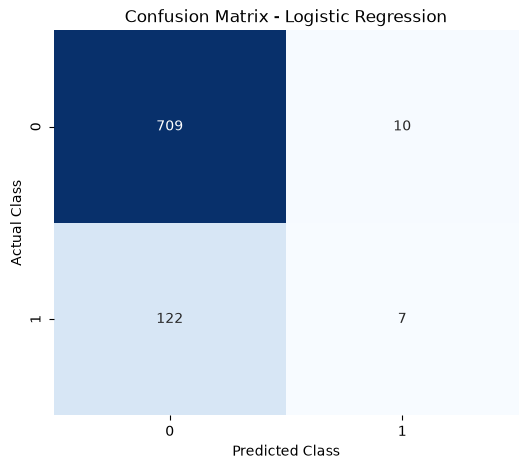

In [20]:
# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

The confusion matrix shows that the Logistic Regression model correctly classified 709 participants who did not develop coronary heart disease and 7 participants who developed the disease. However, the model misclassified 122 positive cases as negative, resulting in a large number of false negatives. This finding explains the low recall observed for the positive class and indicates that the baseline model is biased towards predicting the majority class. Although the model performs well in identifying negative cases, its ability to detect participants at risk of developing coronary heart disease is limited.

### **Classification Report**

The classification report provides a detailed summary of the model's performance for each class by presenting precision, recall, F1-score, and support. These metrics offer a more comprehensive evaluation of the classifier, particularly when dealing with imbalanced datasets.

In [21]:
# Display the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.99      0.91       719
           1       0.41      0.05      0.10       129

    accuracy                           0.84       848
   macro avg       0.63      0.52      0.51       848
weighted avg       0.79      0.84      0.79       848



The classification report indicates that the Logistic Regression model performs substantially better on the majority class than on the minority class. For participants who did not develop coronary heart disease, the model achieved high precision, recall, and F1-score, demonstrating strong predictive performance. In contrast, the positive class exhibited a precision of 0.41, recall of 0.05, and an F1-score of 0.10, indicating that only a small proportion of participants who developed coronary heart disease were correctly identified. These findings further confirm that the baseline Logistic Regression model is affected by the class imbalance present in the dataset and has limited ability to detect minority class instances.

### **Receiver Operating Characteristic (ROC) Curve**

The Receiver Operating Characteristic (ROC) curve is used to evaluate the model's ability to distinguish between the positive and negative classes across different classification thresholds. The Area Under the Curve (ROC-AUC) provides a threshold-independent measure of the model's discriminative performance.

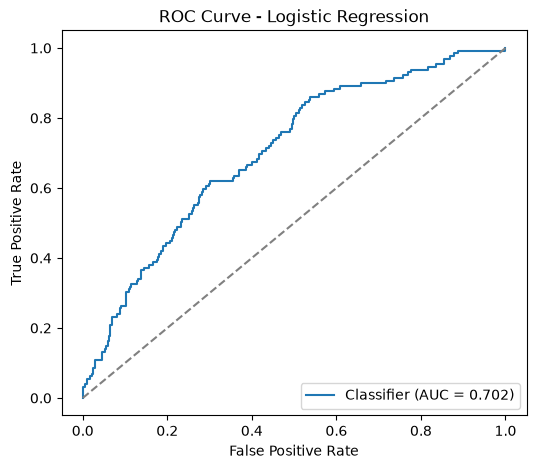

In [29]:
# Compute the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Plot the ROC curve
plt.figure(figsize=(6, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Classifier (AUC = {roc_auc_score(y_test, y_pred_proba):.3f})"
)

# Plot the reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

# Customize the plot
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")

plt.show()

The ROC curve demonstrates the discriminative ability of the Logistic Regression model across different classification thresholds. The model achieved an ROC-AUC score of 0.702, indicating a moderate ability to distinguish between participants who developed coronary heart disease and those who did not. Although the ROC-AUC score suggests that the model possesses reasonable discriminatory power, the low recall observed in previous evaluations indicates that it struggles to identify many positive cases when using the default classification threshold. Consequently, while the baseline model provides a useful benchmark, there is considerable scope for improvement through more advanced algorithms and techniques for handling class imbalance.

### **Model Persistence**

The trained Logistic Regression model is saved for future use in model comparison, further evaluation, and deployment. Saving the fitted model eliminates the need to retrain it each time it is required.

In [30]:
# Save the trained Logistic Regression model
joblib.dump(
    log_reg,
    "../models/logistic_regression_model.pkl"
)

print("Logistic Regression model saved successfully.")

Logistic Regression model saved successfully.


The trained Logistic Regression model was successfully saved to the models directory. The saved model can be reloaded later for prediction, model comparison, or deployment without repeating the training process.

## **Conclusion**

This notebook developed and evaluated a baseline Logistic Regression model for predicting ten-year coronary heart disease risk using the Framingham dataset. The model was trained on standardized predictor variables and assessed using multiple evaluation metrics, including accuracy, precision, recall, F1-score, the confusion matrix, and the ROC curve.

The baseline model achieved good overall accuracy and a moderate ROC-AUC score, indicating a reasonable ability to distinguish between participants who developed coronary heart disease and those who did not. However, its low recall for the positive class revealed a limited ability to identify individuals at risk, largely due to the class imbalance present in the dataset. Consequently, while Logistic Regression provides an important baseline for comparison, its predictive performance for the minority class remains inadequate.

The findings from this notebook establish a benchmark against which more advanced machine learning algorithms and class imbalance handling techniques will be evaluated in subsequent stages of this study.

**Next Phase:** Random Forest